# Fashion Deep Learning Recommendation Systems

#### A classification system is being developed to categorize e-commerce products and recommend similar items based on product images and associated label data.

Download the Dataset from here <a href=https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small>Dataset</a>

<img src='https://miro.medium.com/v2/resize:fit:1400/1*XvMHXOr9pWzky0P7Ew_eLQ.png' width="600" >

### Import Libraries

In [315]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
from tensorflow.keras.applications.resnet50 import ResNet50,preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPool2D
from tensorflow.keras.models import load_model

import cv2

from sklearn.neighbors import NearestNeighbors
import os
from numpy.linalg import norm

### Import Data

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fashion-product-images-small


In [3]:
path = '/kaggle/input/fashion-product-images-small'

In [286]:
df = pd.read_csv("/content/styles.csv", on_bad_lines='skip')

### EDA

In [287]:
df['image'] = df.apply(lambda row: str(row['id']) + ".jpg", axis=1)
df = df.reset_index(drop=True)

In [292]:
df.sample(4)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image
34747,59561,Men,Accessories,Jewellery,Ring,Steel,Summer,2013.0,Casual,Revv Men Steel Ring,59561.jpg
43299,53370,Women,Accessories,Bags,Handbags,Grey,Summer,2012.0,Casual,Puma Women Pink & Grey Bag,53370.jpg
29424,35461,Boys,Apparel,Topwear,Tshirts,Green,Summer,2012.0,Casual,Doodle Boys Printed Green T-shirt,35461.jpg
6574,29239,Men,Footwear,Sandal,Sandals,Black,Summer,2012.0,Casual,ADIDAS Men Pural Black Sandals,29239.jpg


In [327]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
 10  image               44424 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 3.7+ MB


In [328]:
df.shape

(44424, 11)

In [316]:
# Görsel gösterimi
def plot_images(images_dict, nrows=1, ncols=1, figsize=(8, 8)):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.ravel()
    for i, (title, img) in enumerate(images_dict.items()):
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(title)
        axes[i].axis('off')
    plt.tight_layout()

# Resim yolu ve yükleme
def img_path(filename): return f"{path}/images/{filename}"
def load_image(filename): return cv2.imread(img_path(filename))

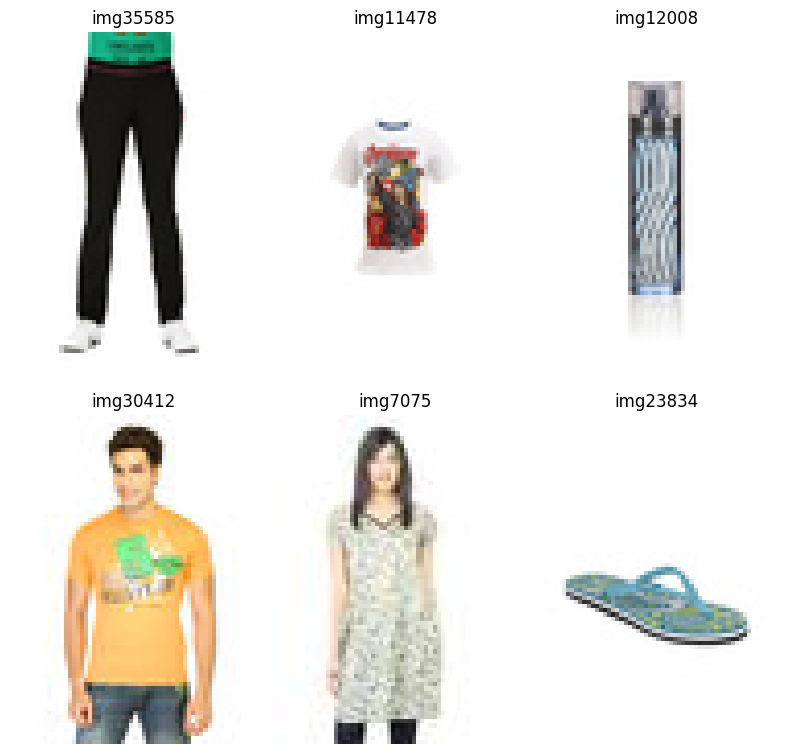

In [325]:
# 6 rastgele görseli (başlık:resim) şeklinde sözlük olarak oluştur
images = {f"img{i}": load_image(row.image) for i, row in df.sample(6).iterrows()}

# 2 satır 3 sütun olarak görselleri çiz
plot_images(images, nrows=2, ncols=3)

In [307]:
df["masterCategory"].value_counts()

,count
masterCategory,
Apparel,21397
Accessories,11274
Footwear,9219
Personal Care,2403
Free Items,105
Sporting Goods,25
Home,1


<Axes: xlabel='masterCategory', ylabel='count'>

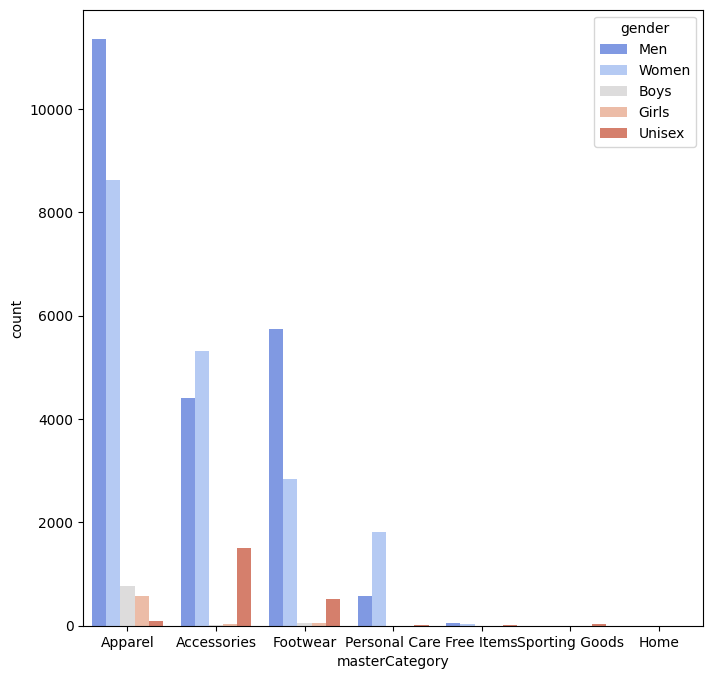

In [329]:
plt.figure(figsize=(8, 8))
sns.countplot(x="masterCategory", data=df, hue="gender", palette='coolwarm')

In [310]:
df["articleType"].value_counts()

,count
articleType,
Tshirts,7067
Shirts,3217
Casual Shoes,2845
Watches,2542
Sports Shoes,2036
...,...
Cushion Covers,1
Mens Grooming Kit,1
Body Wash and Scrub,1


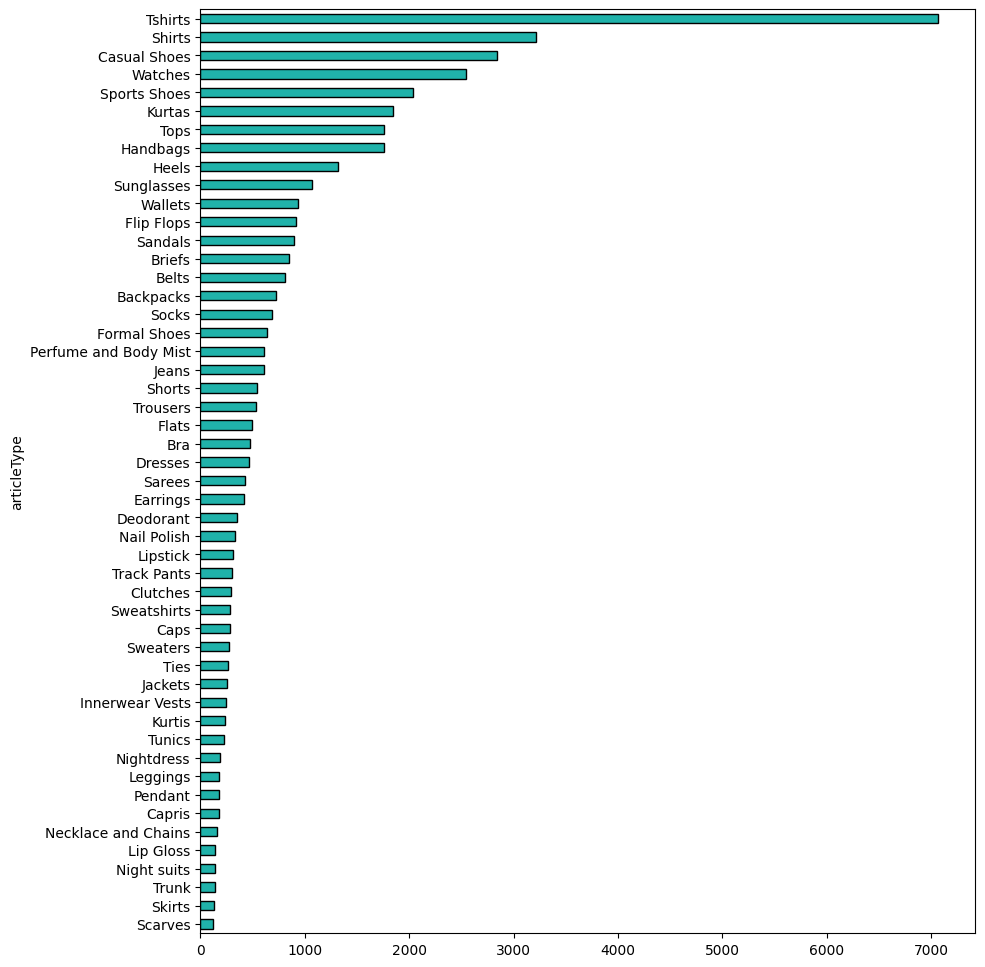

In [326]:
# En çok görülen 50 articleType
top_50_articles = df['articleType'].value_counts().head(50)

# Grafik çizimi
plt.figure(figsize=(10, 12))
bars = top_50_articles.sort_values().plot(kind='barh', color='lightseagreen', edgecolor='black')

In [ ]:
#Extract Filenames from Folder

In [4]:

filenames = []
for file in os.listdir(path + "/images"):
    filenames.append(os.path.join(path + '/images',file))


In [5]:
len(filenames)

44441

In [236]:
#Importing ResNet50 Model and Cofiguration

In [6]:
model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
model.trainable = False

model = tf.keras.models.Sequential([model,
                                   GlobalMaxPool2D()
                                   ])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [237]:
#Extracting Fetaures from Image

In [7]:
def extract_features_from_images(image_path, model):
  try:
    img = image.load_img(image_path, target_size=(224,224))              # 1. Resmi yükle
    img_array = image.img_to_array(img)                                  # 2. NumPy dizisine çevir
    img_expand_dim = np.expand_dims(img_array, axis=0)                   # 3. Batch boyutu ekle
    img_preprocess = preprocess_input(img_expand_dim)                    # 4. ResNet50 için ön işlem
    result = model.predict(img_preprocess).flatten()                     # 5. Modelden çıktı al
    norm_result = result / norm(result)                                  # 6. Normalize et (opsiyonel)
    return norm_result
  except Exception as e:
    print(f"Hata: {image_path} dosyası işlenemedi. {e}")
    return None

In [ ]:
extract_features_from_images(filenames[0], model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


array([0.0004366 , 0.        , 0.02227338, ..., 0.00194947, 0.01470531,
       0.01042839], dtype=float32)

In [ ]:
image_features = []

for file in tqdm(filenames):
    features = extract_features_from_images(file, model)
    if features is not None:
        image_features.append(features)

image_features = np.array(image_features)
np.save("image_features_resnet50.npy", image_features)

In [11]:
np.save("filenames.npy", filenames)

In [12]:
model.save("resnet50_feature_extractor.keras")

In [17]:
image_features = np.load("image_features_resnet50.npy")
filenames = np.load("filenames.npy", allow_pickle=True)

In [18]:
neighbors = NearestNeighbors(n_neighbors=6, algorithm='brute', metric='euclidean')
neighbors.fit(image_features)

NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=6)

In [19]:
model = load_model("resnet50_feature_extractor.keras")

In [273]:
def extract_features_from_images(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_expand_dim = np.expand_dims(img_array, axis=0)
    img_preprocess = preprocess_input(img_expand_dim)
    result = model.predict(img_preprocess, verbose=0).flatten()
    result /= np.linalg.norm(result) + 1e-10
    return result

In [278]:
random_index = random.randint(0, len(filenames)-1)
random_image_path = filenames[random_index]
print(f"Seçilen görsel: {random_image_path}")

Seçilen görsel: /kaggle/input/fashion-product-images-small/images/27587.jpg


In [279]:
query_feature = extract_features_from_images(random_image_path, model)

In [280]:
distances, indices = neighbors.kneighbors([query_feature], n_neighbors=6)

(np.float64(-0.5), np.float64(59.5), np.float64(79.5), np.float64(-0.5))

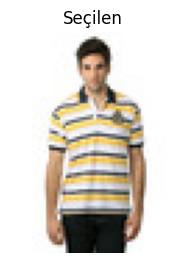

In [281]:
plt.figure(figsize=(15, 10))

# İlk görsel: seçilen
plt.subplot(1, 6, 1)
plt.imshow(Image.open(random_image_path))
plt.title("Seçilen")
plt.axis("off")



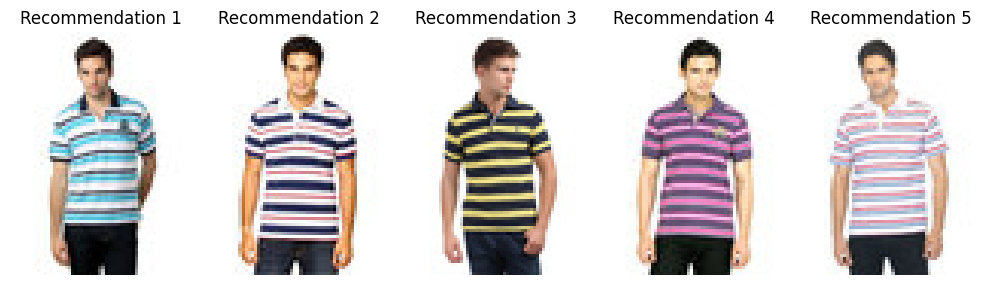

In [282]:
# Benzer 5 öneri
plt.figure(figsize=(12, 4))
for i, idx in enumerate(indices[0][1:], start=2):
    plt.subplot(1, 6, i)
    plt.imshow(Image.open(filenames[idx]))
    plt.title(f"Recommendation {i-1}")
    plt.axis("off")

plt.tight_layout()
plt.show()